# Import Library & Load Dataset

### **Langkah-langkah:**
1. Menggunakan perintah files.upload() dari pustaka google.colab untuk mengunggah file dari komputer ke Google Colab.
2. Setelah menjalankan perintah ini, akan muncul kotak dialog untuk memilih file yang ingin diunggah.
3. File yang diunggah akan disimpan dalam sesi runtime Google Colab dan dapat diakses menggunakan nama file tersebut.

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ridhonurfauzi","key":"ad9dc3e18117b235b15e299347fe6e2d"}'}

### Mengatur kredensial Kaggle API agar dapat mengunduh dataset langsung dari Kaggle ke Google Colab.
### **Langkah-langkah:**
[link text](https://)

1.   Membuat Direktori
*   Jika folder .kaggle belum ada, maka dibuat di dalam direktori /root/.kaggle.
*   Direktori ini digunakan untuk menyimpan file kaggle.json yang berisi API Token dari Kaggle.

2.   Memindahkan File kaggle.json



*   File kaggle.json harus diunggah terlebih dahulu ke Colab (biasanya menggunakan files.upload()).
*   Setelah diunggah, file ini dipindahkan ke direktori /root/.kaggle/.



3. Mengatur Izin Akses


*   Menggunakan os.chmod() untuk mengubah izin file menjadi 600 (hanya pemilik yang bisa membaca & menulis).
*   
Hal ini dilakukan untuk keamanan agar file kaggle.json tidak bisa diakses oleh pihak lain.

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)


### Mengunduh dataset Heart Disease Dataset dari Kaggle ke Google Colab menggunakan perintah Kaggle API.
### **Langkah-langkah:**


1. Pastikan Kredensial Kaggle Sudah Dikonfigurasi
*   Sebelum menjalankan perintah ini, pastikan file kaggle.json sudah dipindahkan ke /root/.kaggle/ dan memiliki izin akses yang benar.
*   Jika belum dikonfigurasi, ikuti langkah-langkah pada bagian sebelumnya untuk mengatur Kaggle API.

2. Menggunakan Perintah kaggle datasets download
*   Perintah !kaggle datasets download -d <username>/<dataset> digunakan untuk mengunduh dataset dari Kaggle.
*   Dalam kasus ini, dataset yang diunduh berasal dari pengguna johnsmith88 dengan nama dataset heart-disease-dataset.

3. Dataset Akan Disimpan dalam Format ZIP
*   Hasil unduhan akan berupa file ZIP yang harus diekstrak terlebih dahulu sebelum digunakan dalam analisis data.



In [ ]:
!kaggle datasets download -d johnsmith88/heart-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


### Mengekstrak dataset Heart Disease Dataset yang telah diunduh dalam format ZIP agar dapat digunakan dalam analisis data.
### Langkah-langkah:


1.   Memeriksa Keberadaan File ZIP


*   File heart-disease-dataset.zip harus sudah ada di direktori kerja.
Jika belum ada, pastikan Anda telah mengunduh dataset menggunakan perintah:
" !kaggle datasets download -d johnsmith88/heart-disease-dataset "



2.   Menggunakan zipfile untuk Mengekstrak Dataset


*   zipfile.ZipFile digunakan untuk membaca file ZIP.
*   Mode "r" (read) memastikan file ZIP dibuka dalam mode baca.
*   extractall("dataset-folder") mengekstrak semua isi file ZIP ke dalam folder bernama dataset-folder.




In [ ]:
import zipfile

with zipfile.ZipFile("heart-disease-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset-folder")

### Sebelum memulai pemrosesan data dan pembuatan model, kita perlu mengimpor berbagai library yang akan digunakan dalam proyek ini.
### Library yang Digunakan:
Pandas (pandas as pd)

1.   Pandas (pandas as pd)
*   Digunakan untuk membaca, memproses, dan menganalisis dataset dalam bentuk DataFrame.
*   Contoh penggunaan: membaca file CSV, membersihkan data, dan eksplorasi dataset.


2.   NumPy (numpy as np)
*   Digunakan untuk perhitungan numerik dan manipulasi array.
*   Berguna dalam pengolahan data dan persiapan dataset untuk machine learning.


3.   Scikit-learn (sklearn.model_selection, sklearn.preprocessing, sklearn.linear_model, sklearn.metrics)
*   train_test_split: Membagi dataset menjadi data latih (train) dan data uji (test).
*   StandardScaler: Melakukan normalisasi atau standarisasi data numerik agar model lebih stabil.
*   LogisticRegression: Model regresi logistik untuk klasifikasi biner (penyakit jantung atau tidak).
*   accuracy_score, classification_report, confusion_matrix: Mengevaluasi performa model menggunakan metrik akurasi, laporan klasifikasi, dan matriks kebingungan.

4.   TensorFlow & Keras (tensorflow as tf, tensorflow.keras)
*   Digunakan untuk membangun dan melatih model deep learning dengan Neural Networks (Jaringan Saraf Tiruan - JST).
*   keras.layers: Menyediakan berbagai layer untuk membangun model deep learning seperti Dense (Fully Connected Layers).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.cm import rainbow
%matplotlib inline



### Memuat dataset ke dalam Pandas DataFrame agar dapat dianalisis dan diproses lebih lanjut.


1.   pd.read_csv("dataset-folder/heart.csv")


*   Membaca dataset dari file CSV yang tersimpan di folder "dataset-folder".
*   Dataset ini berisi informasi medis yang digunakan untuk memprediksi penyakit jantung.


2.   df.head()


*   Menampilkan lima baris pertama dari dataset untuk melihat struktur data, nama kolom, dan sampel data awal.




In [ ]:
df = pd.read_csv("dataset-folder/heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Eksplorasi Data (EDA)

### Melihat ringkasan informasi dataset, termasuk jumlah baris dan kolom, tipe data setiap kolom, serta jumlah nilai yang tidak kosong (non-null).


1.   df.info()
*   Menampilkan ringkasan dataset, seperti:
  *   Jumlah total baris & kolom
  *   Nama kolom
  *   Tipe data masing-masing kolom
  *   Jumlah nilai non-null (berguna untuk mendeteksi data yang hilang)





In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Memeriksa apakah ada data yang hilang (missing values) dalam setiap kolom dataset.
Missing values dapat mempengaruhi kualitas model, sehingga perlu diatasi sebelum melanjutkan ke proses machine learning.


1.   df.isnull()
*   Menghasilkan DataFrame Boolean dengan nilai True jika ada data yang hilang, dan False jika tidak.

2.   df.isnull().sum()
*   Menghitung jumlah True dalam setiap kolom, yang menunjukkan jumlah missing values dalam dataset.

3.   print()
*   Menampilkan jumlah missing values untuk setiap kolom agar lebih mudah dianalisis.


In [ ]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Menganalisis distribusi statistik dari setiap fitur numerik dalam dataset.
Analisis ini membantu kita memahami skala, sebaran, dan karakteristik data sebelum melakukan preprocessing dan pelatihan model machine learning.


*   Fungsi describe() digunakan untuk menampilkan statistik ringkasan dari semua kolom numerik dalam dataset.
*   Statistik yang ditampilkan meliputi:
  *   count → Jumlah data yang tersedia (tidak termasuk missing values).
  *   mean → Rata-rata nilai dalam kolom.
  *   std → Standar deviasi (seberapa tersebar data dari rata-rata).
  *   min → Nilai minimum dalam kolom.
  *   25% → Kuartil pertama (nilai di mana 25% data berada di bawahnya).
  *   50% (median) → Kuartil kedua atau median (nilai tengah).
  *   75% → Kuartil ketiga (nilai di mana 75% data berada di bawahnya).
  *   max → Nilai maksimum dalam kolom.





In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### membersihkan nama kolom dalam dataset dengan menghapus spasi yang mungkin ada di awal atau akhir nama kolom. Ini dilakukan untuk mencegah error saat memanggil kolom dalam analisis atau pemrosesan data lebih lanjut.
*   df.columns → Mengakses daftar nama kolom dalam dataframe.
*   str.strip() → Menghapus spasi di awal dan akhir setiap nama kolom.
    *   Jika terdapat spasi yang tidak terlihat dalam nama kolom, hal ini bisa menyebabkan error saat mengakses kolom menggunakan nama secara eksplisit.
    *   Misalnya, jika kolom bernama ' age ' (dengan spasi di awal atau akhir), kita tidak bisa mengaksesnya dengan df['age'] karena nama aslinya ' age '.
    *   Dengan str.strip(), nama kolom akan dibersihkan sehingga lebih konsisten dan mudah digunakan.



In [ ]:
df.columns = df.columns.str.strip()


# Understanding Data

### Menampilkan matriks korelasi antar fitur dalam dataset menggunakan matplotlib.



1. rcParams['figure.figsize'] = 20, 14
*  Mengatur ukuran gambar (figure size) menjadi 20 x 14 inci untuk memastikan visualisasi cukup besar dan mudah dibaca.
2. plt.matshow(df.corr())
* df.corr() menghitung matriks korelasi antar fitur dalam dataset df.
* plt.matshow() digunakan untuk menampilkan matriks korelasi sebagai heatmap.
3. plt.yticks(np.arange(df.shape[1]), df.columns)
plt.xticks(np.arange(df.shape[1]), df.columns)
* df.shape[1]: Jumlah kolom dalam DataFrame (karena korelasi dihitung antar kolom).
* np.arange(df.shape[1]): Membuat array indeks untuk setiap kolom.
* df.columns: Nama-nama fitur yang akan ditampilkan pada sumbu X dan Y.
4. plt.colorbar()
* Menambahkan color bar untuk menunjukkan skala warna yang merepresentasikan nilai korelasi.



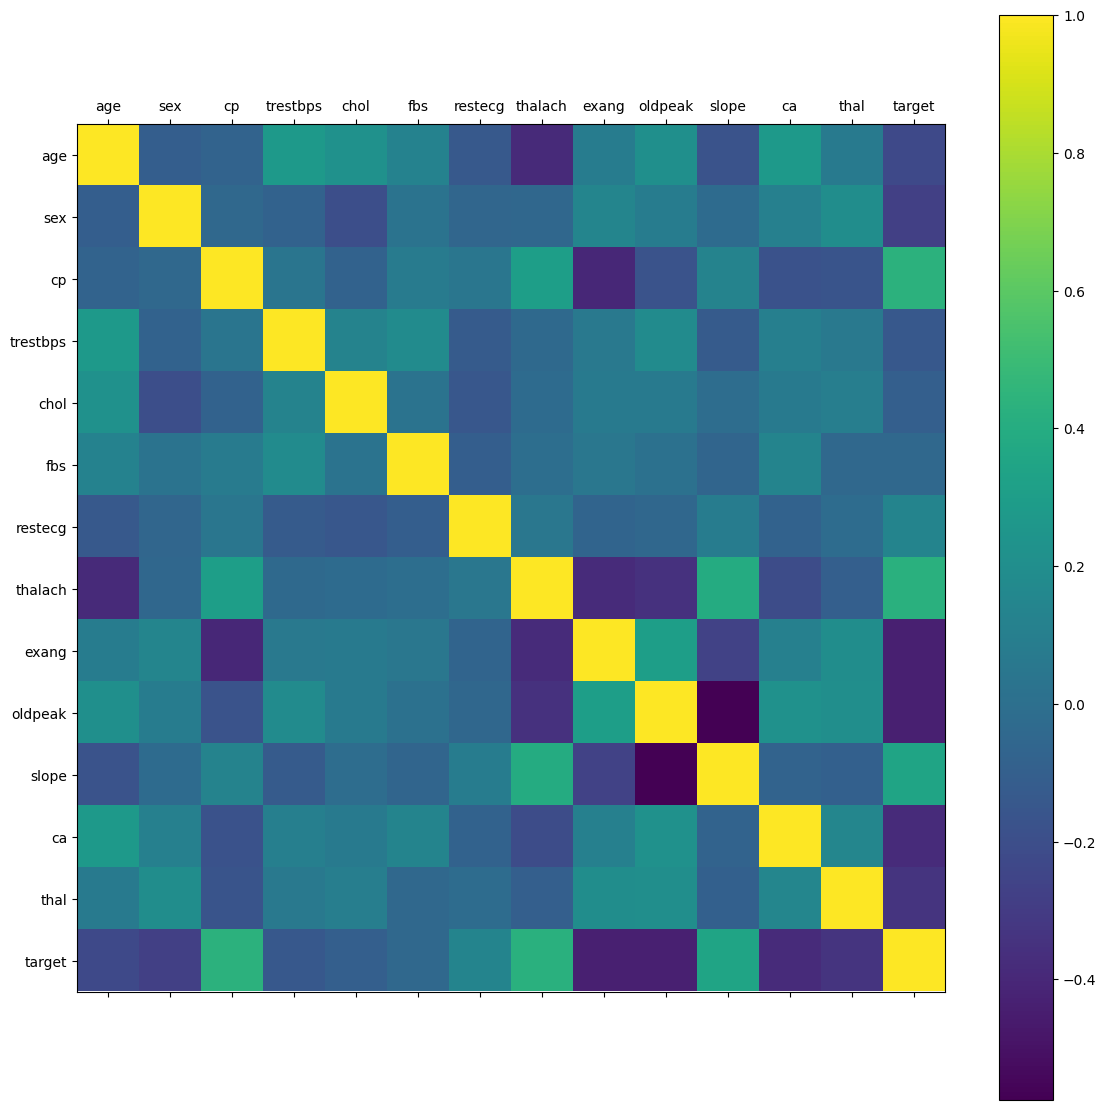

In [ ]:
rcParams['figure.figsize'] = 20, 14
plt.matshow(df.corr())
plt.yticks(np.arange(df.shape[1]), df.columns)
plt.xticks(np.arange(df.shape[1]), df.columns)
plt.colorbar()

### Menampilkan histogram dari setiap fitur numerik dalam dataset menggunakan Pandas dan Matplotlib

1. df.hist()
* df.hist() → Membuat histogram untuk setiap kolom numerik dalam DataFrame df.

* Histogram menunjukkan distribusi data dalam bentuk frekuensi untuk setiap rentang nilai (bin).

* Secara default, df.hist() akan menggunakan 10 bin untuk setiap histogram.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

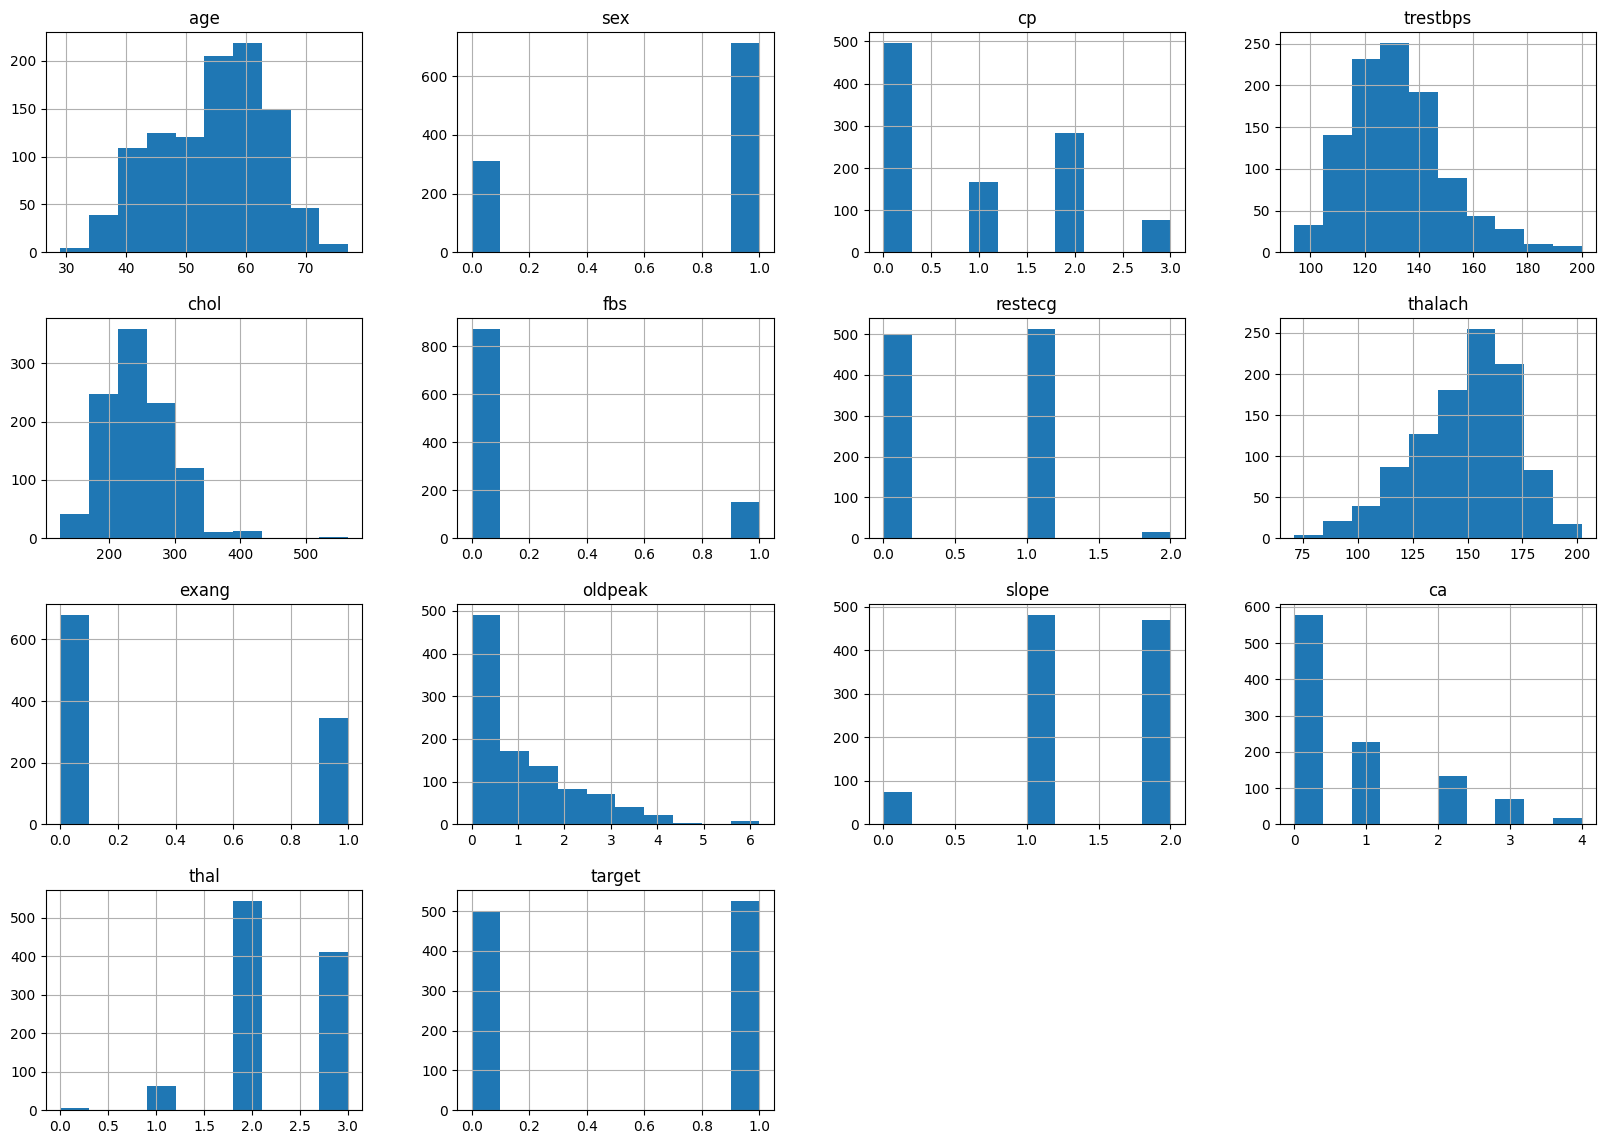

In [ ]:
df.hist()

### Memvisualisasikan distribusi kelas target dalam dataset menggunakan bar chart dari Matplotlib.
Ini berguna untuk memahami proporsi kelas dalam masalah klasifikasi

1. rcParams['figure.figsize'] = 8,6
* Mengatur ukuran gambar menjadi 8x6 inci agar lebih proporsional.

* rcParams: Parameter dari Matplotlib yang digunakan untuk mengontrol tampilan visual.

2. plt.bar(df['target'].unique(), df['target'].value_counts(), color = ['red', 'green'])

* plt.bar(x, y, color=...) → Membuat diagram batang (bar chart) untuk menunjukkan jumlah setiap kelas target dalam dataset.

* df['target'].unique() → Mengambil nilai unik dari kolom target (misalnya, 0 dan 1 dalam klasifikasi biner).

* df['target'].value_counts() → Menghitung jumlah kemunculan setiap kelas target dalam dataset.

* color=['red', 'green'] → Memberikan warna merah untuk kelas 0 dan hijau untuk kelas 1.

3. plt.xticks([0, 1])
* Menetapkan label pada sumbu X sebagai 0 dan 1, yang mewakili kelas target.

4. plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')
* plt.xlabel('Target Classes') → Memberikan label sumbu X sebagai "Target Classes".
* plt.ylabel('Count') → Memberikan label sumbu Y sebagai "Count" untuk menunjukkan jumlah kemunculan setiap kelas.
* plt.title('Count of each Target Class') → Menambahkan judul grafik untuk menjelaskan bahwa visualisasi ini menunjukkan jumlah masing-masing kelas target.

Text(0.5, 1.0, 'Count of each Target Class')

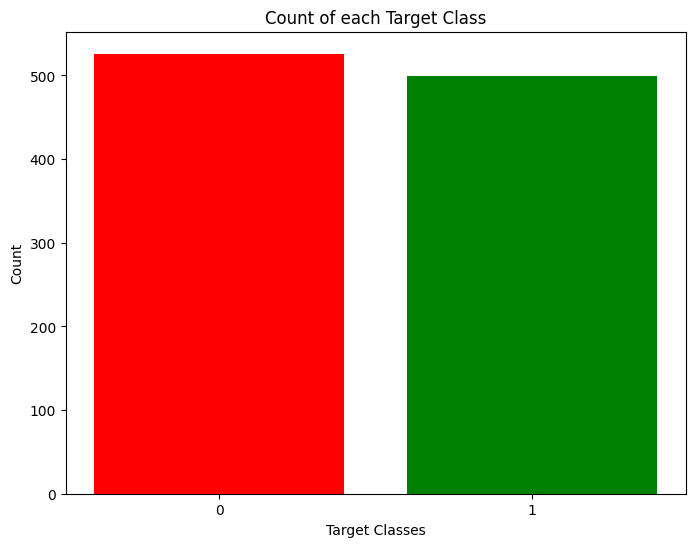

In [ ]:
rcParams['figure.figsize'] = 8,6
plt.bar(df['target'].unique(), df['target'].value_counts(), color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')

# Preprocessing Data

### Melakukan One-Hot Encoding pada kolom-kolom kategorikal dalam dataset menggunakan pd.get_dummies().
Teknik ini penting dalam machine learning karena algoritma biasanya tidak dapat bekerja langsung dengan data kategorikal.

1. df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True)

* pd.get_dummies(df, columns=[...]) → Mengonversi kolom kategorikal menjadi representasi numerik dengan One-Hot Encoding.
* columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'] → Daftar kolom kategorikal yang akan dikodekan.
* drop_first=True → Menghindari dummy variable trap dengan menghapus satu kategori dari setiap kolom (misalnya, jika sex memiliki nilai 0 dan 1, hanya sex_1 yang disimpan).


In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True)
print(df_encoded.head())


   age  trestbps  chol  thalach  oldpeak  target  sex_1   cp_1   cp_2   cp_3  \
0   52       125   212      168      1.0       0   True  False  False  False   
1   53       140   203      155      3.1       0   True  False  False  False   
2   70       145   174      125      2.6       0   True  False  False  False   
3   61       148   203      161      0.0       0   True  False  False  False   
4   62       138   294      106      1.9       0  False  False  False  False   

   ...  exang_1  slope_1  slope_2   ca_1   ca_2   ca_3   ca_4  thal_1  thal_2  \
0  ...    False    False     True  False   True  False  False   False   False   
1  ...     True    False    False  False  False  False  False   False   False   
2  ...     True    False    False  False  False  False  False   False   False   
3  ...    False    False     True   True  False  False  False   False   False   
4  ...    False     True    False  False  False   True  False   False    True   

   thal_3  
0    True  
1    Tru

### Melakukan normalisasi fitur numerik menggunakan StandardScaler dari sklearn.preprocessing.
Normalisasi ini bertujuan untuk menyamakan skala setiap fitur agar model dapat belajar dengan lebih baik dan stabil.


1.   scaler = StandardScaler()
*   Membuat objek StandardScaler untuk melakukan normalisasi data.
*   StandardScaler akan mengubah data menjadi distribusi dengan mean 0 dan standar deviasi 1.
*   Normalisasi ini penting untuk algoritma machine learning agar semua fitur memiliki skala yang sama.

2.   numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


*   Menentukan kolom fitur numerik yang akan dinormalisasi.
*   age → Usia pasien.
*   trestbps → Tekanan darah istirahat.
*   chol → Kolesterol dalam darah.
*   thalach → Detak jantung maksimum yang dicapai.
*   oldpeak → Depresi ST yang disebabkan oleh olahraga relatif terhadap istirahat.

3. df[numerical_features] = scaler.fit_transform(df[numerical_features])


*   fit_transform() menghitung mean dan standar deviasi dari data, lalu menerapkan transformasi
*   Hasilnya: Data setiap fitur memiliki mean = 0 dan standar deviasi = 1.



In [ ]:
scaler = StandardScaler()
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

### Memisahkan fitur (X) dan label (y) dalam dataset.


*   Fitur (X) → Berisi variabel yang digunakan sebagai input model.
*   Label (y) → Berisi variabel yang menjadi target prediksi.



1.   X = df.drop(columns=['target'])


*   Menghapus kolom target dari dataframe df.
*   X hanya berisi variabel prediktor yang akan digunakan untuk melatih model.



2.   y = df['target']


*   Menyimpan kolom target sebagai variabel output (label).
*   Label ini berisi nilai 0 dan 1, di mana:
  *   0 → Tidak memiliki penyakit jantung
  *   1 → Memiliki penyakit jantung

In [ ]:
X = df.drop(['target'],axis=1)
y = df['target']

## Membagi dataset menjadi dua bagian
1.   Data Latih (X_train, y_train) → Digunakan untuk melatih model.

2.   Data Uji (X_test, y_test) → Digunakan untuk mengevaluasi performa model.

3. train_test_split(X, y, test_size=0.2, random_state=42)
*   Memisahkan data menjadi 80% data latih dan 20% data uji.
*   test_size=0.2 → 20% data akan digunakan untuk pengujian.
*   random_state=42 → Memastikan pembagian data konsisten setiap kali dijalankan.
*   Secara otomatis, data akan teracak sebelum dibagi untuk menghindari bias.
4. Variabel yang dihasilkan:



*   X_train → Fitur untuk training (80% dari X).
*   X_test → Fitur untuk testing (20% dari X).
*   y_train → Label untuk training (80% dari y).
*   y_test → Label untuk testing (20% dari y).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)


## Memeriksa jumlah fitur yang digunakan dalam training dan memastikan semua fitur sudah sesuai sebelum pelatihan model.



1.   X_train.shape[1]
*   .shape mengembalikan dimensi dari DataFrame.
*   X_train.shape[1] akan mengambil jumlah kolom, yang merupakan jumlah fitur yang digunakan untuk training.
*   Ini memastikan tidak ada fitur yang hilang atau kelebihan sebelum model dilatih.

2.  X_train.columns.tolist()


*   .columns mengembalikan daftar nama fitur dalam dataset.
*   .tolist() mengubah daftar kolom menjadi list Python, sehingga lebih mudah dibaca.
*   Berguna untuk memastikan semua fitur yang diharapkan ada sebelum model dilatih.

In [ ]:
print(f"Jumlah fitur saat training: {X_train.shape[1]}")

print(f"Nama fitur saat training: {X_train.columns.tolist()}")
feature_order = X_train.columns.tolist()


Jumlah fitur saat training: 13
Nama fitur saat training: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


# Membangun Model Machine Learning

In [ ]:
model_results = {}

### K Neighbors Classifier
melatih dan mengevaluasi model K-Nearest Neighbors (KNN) dengan berbagai nilai K (jumlah tetangga terdekat) untuk menemukan K terbaik yang memberikan skor akurasi tertinggi
1. knn_scores = []
* Inisialisasi list kosong untuk menyimpan skor akurasi model KNN dengan berbagai nilai K.
2. for k in range(1, 21):
* Melakukan iterasi dari K = 1 hingga K = 20.
* K adalah jumlah tetangga terdekat yang digunakan oleh model KNN.
3.     knn_classifier = KNeighborsClassifier(n_neighbors = k)
* Membuat model KNN dengan nilai K yang sedang diuji.

* KNeighborsClassifier(n_neighbors=k) → Model akan mencari K tetangga terdekat untuk membuat prediksi.

4.     knn_classifier.fit(X_train, y_train)
* Melatih model KNN dengan dataset training (X_train, y_train).

* Model akan belajar hubungan antara fitur (X_train) dan label (y_train).

5.     knn_scores.append(knn_classifier.score(X_test, y_test))
*  Mengukur akurasi model dengan score(X_test, y_test), yang menghitung proporsi prediksi benar terhadap total data uji.

* Menyimpan skor akurasi dalam list knn_scores untuk dianalisis lebih lanjut.

In [ ]:
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    knn_classifier.fit(X_train, y_train)
    knn_scores.append(knn_classifier.score(X_test, y_test))

### Memvisualisasikan bagaimana akurasi model K-Nearest Neighbors (KNN) berubah berdasarkan jumlah tetangga (K)
1. plt.plot([k for k in range(1, 21)], knn_scores, color='red')
* Membuat grafik garis untuk melihat bagaimana skor akurasi berubah dengan nilai K.

* range(1, 21) → Nilai K dari 1 hingga 20.

* knn_scores → List yang menyimpan skor akurasi untuk setiap K.

* color='red' → Warna garis merah untuk grafik.

2. for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
* Menambahkan teks pada setiap titik di grafik untuk menampilkan nilai K dan akurasinya.

* (i, knn_scores[i-1]) → Posisi teks sesuai nilai K dan akurasi yang diperoleh.

* Ini membantu kita melihat nilai spesifik dari akurasi setiap K.

3. plt.xticks([i for i in range(1, 21)])
* Menyesuaikan label sumbu X agar menunjukkan angka K dari 1 hingga 20.

* Memastikan setiap K memiliki label yang jelas di sumbu X.

4. plt.xlabel('Number of Neighbors (K)')
* Memberi label pada sumbu X sebagai "Number of Neighbors (K)" untuk menunjukkan bahwa ini adalah jumlah tetangga yang digunakan dalam KNN.
5. plt.ylabel('Scores')
* Memberi label pada sumbu Y sebagai "Scores" untuk menunjukkan bahwa nilai ini adalah skor akurasi model.

6. plt.title('K Neighbors Classifier scores for different K values')
* Memberi judul grafik sebagai "K Neighbors Classifier scores for different K values" untuk menjelaskan isi grafik.

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

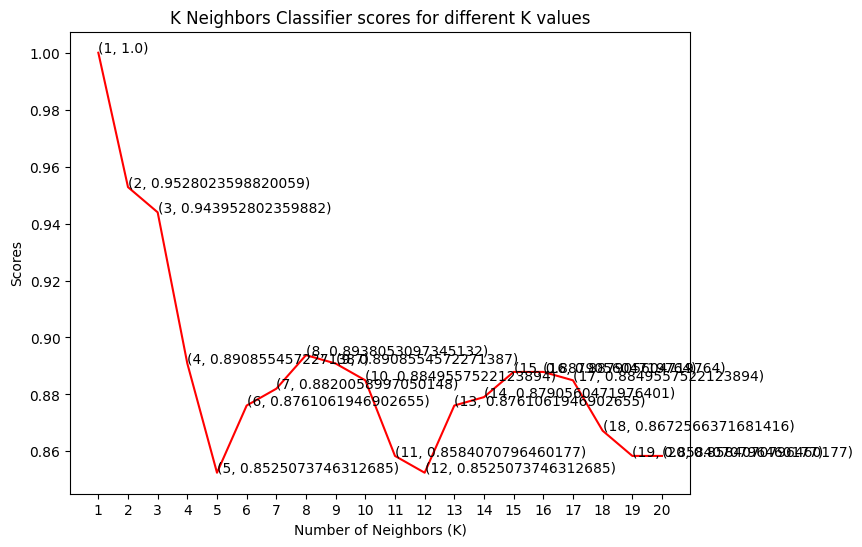

In [ ]:

plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
plt.xticks([i for i in range(1, 21)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

### Menampilkan akurasi model K-Nearest Neighbors (KNN) ketika jumlah tetangga (K) adalah 8.
1. print("The score for K Neighbors Classifier is {}% with {} neighbors.".format(knn_scores[7]*100, 8))
* knn_scores[7] → Mengambil skor akurasi dari list knn_scores pada indeks 7.

* Mengapa indeks 7?

  * Karena dalam pemrograman Python, indeks dimulai dari 0.

  * K=8 berada di indeks 7 (knn_scores[7]).

2. .format(knn_scores[7]*100, 8)
* knn_scores[7] * 100 → Mengonversi skor menjadi persentase (misalnya, 0.83 → 83%).

* 8 → Menampilkan jumlah tetangga yang digunakan.


In [ ]:

print("The score for K Neighbors Classifier is {}% with {} nieghbors.".format(knn_scores[7]*100, 8))

The score for K Neighbors Classifier is 89.38053097345133% with 8 nieghbors.


Simpan Hasil model ke dalam model result dengan nama KNN untuk nantinya di bandingkan dengan algortima model lain

In [ ]:
model_results["KNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn, average='weighted'),
    "Recall": recall_score(y_test, y_pred_knn, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_knn, average='weighted')
}

### Support Vector Classifier
Melatih dan mengevaluasi model Support Vector Machine (SVM) dengan berbagai jenis kernel, yaitu:

1. Linear

2. Polynomial (Poly)

3. Radial Basis Function (RBF)

4. Sigmoid

Tujuan dari kode ini adalah menentukan kernel terbaik berdasarkan akurasi model pada data uji (X_test, y_test).

1. svc_scores = []
* Inisialisasi list kosong untuk menyimpan skor akurasi dari masing-masing kernel.
2. kernels = ['linear', 'poly', 'rbf', 'sigmoid']
* Daftar kernel SVM yang akan diuji.

* linear → Kernel linear cocok untuk data yang dapat dipisahkan secara linier.

* poly → Kernel polinomial untuk menangani hubungan non-linear.

* rbf → Kernel RBF untuk menangani data yang lebih kompleks dan non-linear.

* sigmoid → Kernel sigmoid mirip dengan fungsi aktivasi dalam jaringan saraf.

3. for i in range(len(kernels)):
* Melakukan iterasi untuk setiap kernel dalam list kernels.

* len(kernels) bernilai 4, sehingga iterasi berjalan sebanyak 4 kali (untuk linear, poly, rbf, dan sigmoid).

4.     svc_classifier = SVC(kernel = kernels[i])
* Membuat model Support Vector Classifier (SVC) dengan kernel yang sedang diuji.

* SVC(kernel = kernels[i]) → Menggunakan kernel ke-i dari list kernels.

5.     svc_classifier.fit(X_train, y_train)
* Melatih model SVM dengan data training (X_train, y_train).
* Model akan belajar memisahkan data ke dalam dua kelas berdasarkan fitur yang ada.

6.     svc_scores.append(svc_classifier.score(X_test, y_test))
*  Mengukur akurasi model dengan score(X_test, y_test), yang menghitung persentase prediksi benar terhadap total data uji.

* Menyimpan skor akurasi dalam list svc_scores untuk dibandingkan nanti.


In [ ]:
svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in range(len(kernels)):
    svc_classifier = SVC(kernel = kernels[i])
    svc_classifier.fit(X_train, y_train)
    svc_scores.append(svc_classifier.score(X_test, y_test))

Membandingkan performa model Support Vector Machine (SVM) berdasarkan jenis kernel dengan menggunakan grafik batang (bar chart)
1. colors = rainbow(np.linspace(0, 1, len(kernels)))
* np.linspace(0, 1, len(kernels))

  * Membuat nilai numerik yang tersebar merata antara 0 dan 1 sebanyak jumlah kernel (len(kernels)).

* rainbow()

  * Menghasilkan warna dari skala rainbow colormap.

  * Setiap kernel akan memiliki warna yang berbeda.

2. plt.bar(kernels, svc_scores, color = colors)
* plt.bar(kernels, svc_scores, color = colors)
  * Membuat grafik batang, dengan:
    * Sumbu X → Nama kernel (linear, poly,rbf, sigmoid).
    * Sumbu Y → Skor akurasi yang disimpan dalam svc_scores.
    * Warna → Diambil dari variabel colors.
3. for i in range(len(kernels)):
    plt.text(i, svc_scores[i], svc_scores[i])
* plt.text(i, svc_scores[i], svc_scores[i])
  * Menempatkan teks nilai akurasi di atas setiap batang.
  * i → Posisi sumbu X untuk kernel tertentu.
  * svc_scores[i] → Posisi sumbu Y untuk menampilkan nilai akurasi.
4. plt.xlabel('Kernels')
plt.ylabel('Scores')
plt.title('Support Vector Classifier scores for different kernels')
* plt.xlabel('Kernels') → Label sumbu X sebagai "Kernels".
* plt.ylabel('Scores') → Label sumbu Y sebagai "Scores" (Akurasi).
* plt.title('Support Vector Classifier scores for different kernels') → Judul grafik.

Text(0.5, 1.0, 'Support Vector Classifier scores for different kernels')

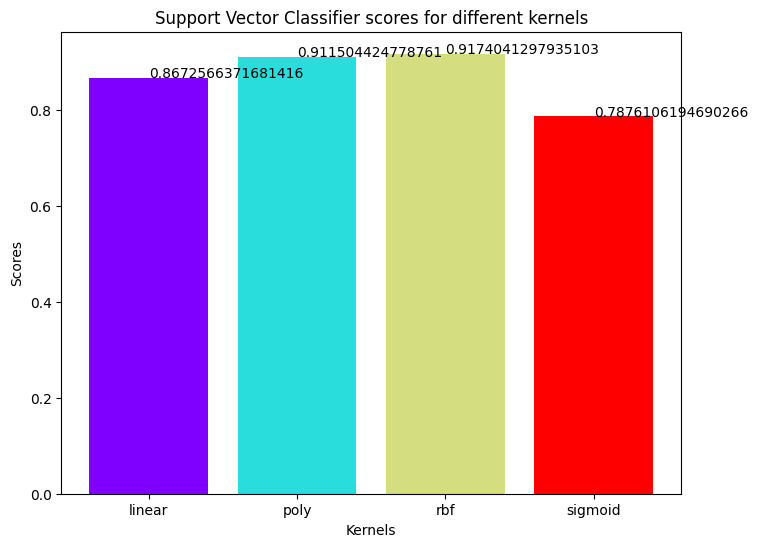

In [ ]:
colors = rainbow(np.linspace(0, 1, len(kernels)))
plt.bar(kernels, svc_scores, color = colors)
for i in range(len(kernels)):
    plt.text(i, svc_scores[i], svc_scores[i])
plt.xlabel('Kernels')
plt.ylabel('Scores')
plt.title('Support Vector Classifier scores for different kernels')

Menampilkan akurasi model Support Vector Machine (SVM) yang menggunakan kernel linear.
1. print("The score for Support Vector Classifier is {}% with {} kernel.".format(svc_scores[0]*100, 'linear'))
* Menggunakan format() untuk memasukkan nilai akurasi dan nama kernel ke dalam string.
* Bagian svc_scores[0] * 100
  * svc_scores[0] → Mengambil skor akurasi untuk kernel linear (karena kernel linear ada di indeks ke-0 dalam list svc_scores).
  * 100 → Mengonversi skor dari desimal ke persentase.
* Bagian 'linear'
  * Memasukkan nama kernel yang digunakan ke dalam teks output.

In [ ]:
print("The score for Support Vector Classifier is {}% with {} kernel.".format(svc_scores[0]*100, 'linear'))

The score for Support Vector Classifier is 86.72566371681415% with linear kernel.


Simpan Hasil model ke dalam model result dengan nama SVM untuk nantinya di bandingkan dengan algortima model lain

In [ ]:
model_results["SVM"] = {
    "Accuracy": accuracy_score(y_test, y_pred_svc),
    "Precision": precision_score(y_test, y_pred_svc, average='weighted'),
    "Recall": recall_score(y_test, y_pred_svc, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_svc, average='weighted')
}

### Decision Tree Classifier
Mengevaluasi performa model Decision Tree dengan jumlah fitur yang berbeda.
1. dt_scores = []
* dt_scores digunakan untuk menyimpan akurasi model Decision Tree pada setiap jumlah fitur yang diuji.
2. for i in range(1, len(X.columns) + 1):
* len(X.columns) → Menghitung jumlah total fitur dalam dataset.
* Loop dimulai dari 1 hingga len(X.columns) + 1 untuk menguji model dengan jumlah fitur mulai dari 1 hingga total fitur yang tersedia.
3. dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
* max_features = i → Jumlah fitur yang digunakan dalam model di setiap iterasi.
* random_state = 0 → Agar hasil eksperimen tetap konsisten setiap kali dijalankan.
4. dt_classifier.fit(X_train, y_train)
* Model dilatih menggunakan dataset X_train dan y_train.
5. dt_scores.append(dt_classifier.score(X_test, y_test))
* dt_classifier.score(X_test, y_test)
  * Mengukur akurasi model pada data uji (X_test, y_test).
  * Akurasi ini ditambahkan ke dalam list dt_scores untuk dianalisis lebih lanjut.

In [ ]:
dt_scores = []
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
    dt_classifier.fit(X_train, y_train)
    dt_scores.append(dt_classifier.score(X_test, y_test))

In [ ]:
print(len(dt_scores))

13


Memplot grafik akurasi Decision Tree berdasarkan jumlah fitur maksimum (max_features) yang digunakan dalam mode
1. plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
* plt.plot(x, y, color='green')
  * x: Jumlah fitur (max_features), dimulai dari 1 hingga total fitur dalam dataset (len(X.columns)).
  * y: Akurasi model untuk setiap jumlah fitur (tersimpan dalam dt_scores).
  * Warna garis hijau menunjukkan tren akurasi dengan jumlah fitur yang meningkat.

2. for i in range(1, len(X.columns) + 1):plt.text(i, dt_scores[i-1], (i, dt_scores[i-1]))
* Loop untuk menampilkan nilai akurasi di setiap titik grafik.
* plt.text(x, y, teks)
  * x = i → Posisi sumbu X (jumlah fitur).
  * y = dt_scores[i-1] → Posisi sumbu Y (akurasi model untuk jumlah fitur ke-i).
  * Menampilkan teks (i, dt_scores[i-1]) sebagai informasi tambahan di grafik.
  
3. plt.xticks([i for i in range(1, len(X.columns) + 1)])
* plt.xticks([i for i in range(1, len(X.columns) + 1)])

4. plt.xlabel('Max features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different number of maximum features')
* plt.xlabel('Max features') → Label sumbu X sebagai jumlah fitur maksimum (max_features).
* plt.ylabel('Scores') → Label sumbu Y sebagai skor akurasi model.
* plt.title(...) → Judul grafik untuk menjelaskan bahwa ini adalah visualisasi akurasi model Decision Tree dengan berbagai jumlah fitur maksimum.


Text(0.5, 1.0, 'Decision Tree Classifier scores for different number of maximum features')

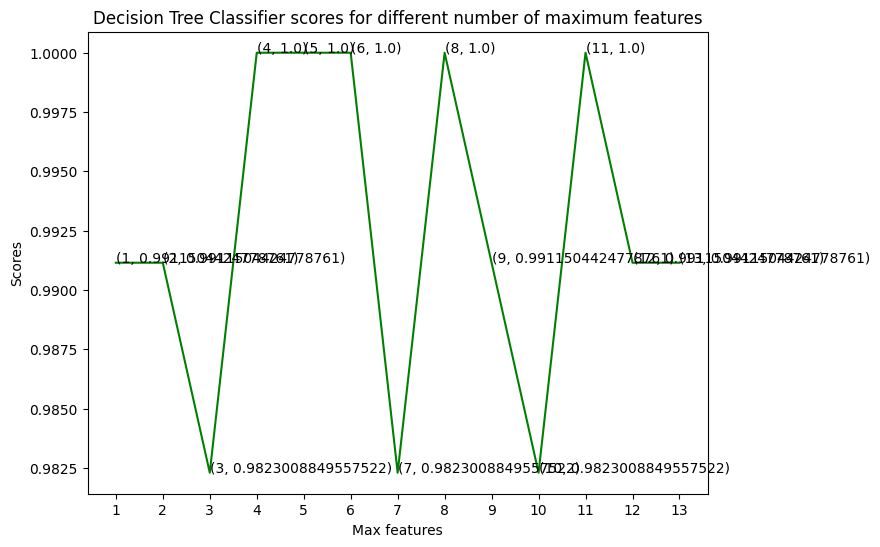

In [ ]:
plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
for i in range(1, len(X.columns) + 1):
    plt.text(i, dt_scores[i-1], (i, dt_scores[i-1]))
plt.xticks([i for i in range(1, len(X.columns) + 1)])
plt.xlabel('Max features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different number of maximum features')

1. dt_scores[12] → Mengambil Akurasi Model
* dt_scores adalah list yang menyimpan akurasi model Decision Tree untuk berbagai jumlah fitur maksimum (max_features).
* dt_scores[12] → Mengambil akurasi untuk model dengan 13 fitur (index 12, karena indeks dimulai dari 0).
* Dikalikan 100 agar hasilnya dalam persentase (%).

2. {} → Format String untuk Menampilkan Data
* format(dt_scores[12]*100, [2,4,18]) digunakan untuk memasukkan nilai akurasi dan daftar fitur ke dalam teks.
* {} pertama → Berisi akurasi model dalam persen.
* {} kedua → Berisi daftar fitur [2,4,18] yang digunakan dalam model.

3. Menampilkan Hasil dalam Bentuk Teks
* Model Decision Tree dengan 13 fitur memiliki akurasi 85.32%.
* Fitur yang digunakan adalah [2,4,18] (misalnya, usia, tekanan darah, jumlah pembuluh darah yang terdeteksi).

In [ ]:
print("The score for Decision Tree Classifier is {}% with {} maximum features.".format(dt_scores[12]*100, [2,4,18]))

The score for Decision Tree Classifier is 99.11504424778761% with [2, 4, 18] maximum features.


Simpan Hasil model ke dalam model result dengan nama Decision Tree untuk nantinya di bandingkan dengan algortima model lain

In [ ]:
model_results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, average='weighted'),
    "Recall": recall_score(y_test, y_pred_dt, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_dt, average='weighted')
}

Random Forset Classifier
Mengevaluasi performa model Random Forest dengan berbagai jumlah estimator (n_estimators) dan mencatat akurasinya.
1. rf_scores = []
estimators = [10, 100, 200, 500, 1000]
* rf_scores → List kosong untuk menyimpan akurasi model pada setiap jumlah estimator.
* estimators → List yang berisi jumlah estimator yang akan diuji:
  * 10, 100, 200, 500, dan 1000 pohon dalam Random Forest.
2. for i in estimators: rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0) rf_classifier.fit(X_train, y_train) rf_scores.append(rf_classifier.score(X_test, y_test))
* Loop untuk menguji berbagai jumlah estimator (i dalam estimators).
* Membuat model Random Forest dengan n_estimators = i:
  * RandomForestClassifier(n_estimators = i, random_state = 0) → Membangun model dengan i pohon keputusan.
  * random_state = 0 → Agar hasil tetap konsisten setiap kali dijalankan.
* Melatih model dengan data latih (X_train, y_train).
* Menghitung akurasi model pada data uji (X_test, y_test):
  * rf_classifier.score(X_test, y_test) → Menghitung akurasi model.
  * Akurasi disimpan dalam rf_scores untuk setiap jumlah estimator.




In [ ]:
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    rf_classifier.fit(X_train, y_train)
    rf_scores.append(rf_classifier.score(X_test, y_test))

Membuat diagram batang (bar chart) yang menunjukkan akurasi model Random Forest berdasarkan jumlah estimator (n_estimators).
1. colors = rainbow(np.linspace(0, 1, len(estimators)))
* Menggunakan rainbow colormap untuk memberikan warna yang bervariasi pada batang diagram.
* np.linspace(0, 1, len(estimators)) → Menghasilkan nilai yang terdistribusi merata antara 0 hingga 1 untuk mewakili warna di colormap.
2. plt.bar([i for i in range(len(estimators))], rf_scores, color = colors, width = 0.8)
* Sumbu X (x) → Indeks estimators [0,1,2,3,4].
* Sumbu Y (y) → Nilai akurasi dari rf_scores.
* color = colors → Menggunakan warna dari colormap rainbow.
* width = 0.8 → Mengatur lebar batang.
3. for i in range(len(estimators)):
    plt.text(i, rf_scores[i], rf_scores[i])
* Menampilkan nilai akurasi di atas setiap batang.
* plt.text(x, y, text) → Menempatkan teks di koordinat (x, y).
  * x = i → Indeks estimator.
  * y = rf_scores[i] → Nilai akurasi model.
  * rf_scores[i] → Menampilkan teks akurasi pada grafik.
4. plt.xticks(ticks = [i for i in range(len(estimators))], labels = [str(estimator) for estimator in estimators])
* Mengatur label sumbu X agar sesuai dengan nilai estimators (10, 100, 200, 500, 1000).
* ticks → Menentukan posisi label di sumbu X.
* labels → Menentukan teks yang ditampilkan, yaitu jumlah estimator dalam bentuk string.
5. plt.xlabel('Number of estimators')
plt.ylabel('Scores')
plt.title('Random Forest Classifier scores for different number of estimators')
* plt.xlabel('Number of estimators') → Menambahkan label sumbu X ("Number of estimators").
* plt.ylabel('Scores') → Menambahkan label sumbu Y ("Scores").
* plt.title('Random Forest Classifier scores for different number of estimators') → Memberikan judul grafik.

Text(0.5, 1.0, 'Random Forest Classifier scores for different number of estimators')

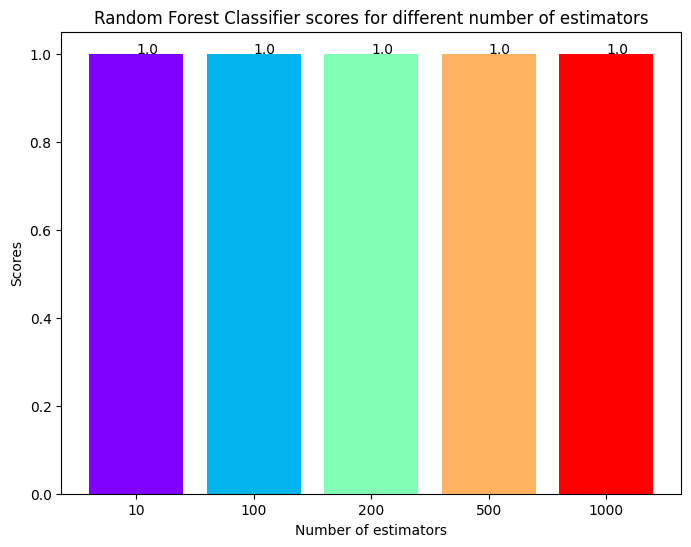

In [ ]:
colors = rainbow(np.linspace(0, 1, len(estimators)))
plt.bar([i for i in range(len(estimators))], rf_scores, color = colors, width = 0.8)
for i in range(len(estimators)):
    plt.text(i, rf_scores[i], rf_scores[i])
plt.xticks(ticks = [i for i in range(len(estimators))], labels = [str(estimator) for estimator in estimators])
plt.xlabel('Number of estimators')
plt.ylabel('Scores')
plt.title('Random Forest Classifier scores for different number of estimators')

Menampilkan akurasi model Random Forest Classifier berdasarkan jumlah estimator tertentu (n_estimators).

1. print("The score for Random Forest Classifier is {}% with {} estimators.".format(rf_scores[1]*100, [100, 500]))
* rf_scores[1] * 100 → Menghitung Akurasi dalam Persentase
rf_scores adalah list yang berisi nilai akurasi model untuk berbagai jumlah estimator.
* rf_scores[1] → Mengambil nilai akurasi pada indeks ke-1, yang sesuai dengan jumlah estimator 100.
* *100 → Mengonversi nilai akurasi ke dalam persentase (%).

2. [100, 500] → Menampilkan Daftar Jumlah Estimator
* [100, 500] → Adalah list yang berisi jumlah estimator yang dianggap relevan.

In [ ]:
print("The score for Random Forest Classifier is {}% with {} estimators.".format(rf_scores[1]*100, [100, 500]))

The score for Random Forest Classifier is 100.0% with [100, 500] estimators.


Simpan Hasil model ke dalam model result dengan nama Random Forest untuk nantinya di bandingkan dengan algortima model lain

In [ ]:
model_results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average='weighted'),
    "Recall": recall_score(y_test, y_pred_rf, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_rf, average='weighted')
}

## Membuat model jaringan saraf tiruan (Neural Network) menggunakan TensorFlow dan Keras untuk klasifikasi penyakit jantung.



1.   keras.Sequential([])
*   Digunakan untuk membuat model berlapis (sequential model) di Keras.
*   Setiap layer akan ditambahkan berurutan sesuai urutan dalam list [ ].

2.  layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],))
*   Layer pertama:
  *   16 neuron di hidden layer pertama.
  *   ReLU (Rectified Linear Unit) sebagai fungsi aktivasi untuk menangani nilai non-linear.
  *   input_shape=(X_train.shape[1],) memastikan model menerima jumlah fitur yang sesuai dengan data training.
3. layers.Dense(8, activation='relu')
*   Hidden layer kedua dengan 8 neuron.
*   Menggunakan ReLU activation untuk membantu model belajar pola kompleks.

4. layers.Dense(1, activation='sigmoid')
*   Output layer dengan 1 neuron karena kita melakukan klasifikasi biner (0 atau 1).

*   Menggunakan sigmoid activation sehingga output berada dalam rentang 0 hingga 1.

*   Jika output > 0.5, maka dikategorikan sebagai "Memiliki Penyakit Jantung".

*   Jika output ≤ 0.5, maka dikategorikan sebagai "Tidak Memiliki Penyakit Jantung".



In [ ]:
model_nn = keras.Sequential([
    layers.Dense(132, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Output layer untuk klasifikasi biner
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1.  compile() digunakan untuk mengonfigurasi model sebelum pelatihan.

2. optimizer='adam'
*   Menggunakan Adam optimizer karena memiliki fitur adaptif dalam mengatur learning rate, sehingga sering memberikan hasil yang lebih baik.

3.  loss='binary_crossentropy'
*   Karena ini adalah klasifikasi biner (0 atau 1), kita menggunakan fungsi binary cross-entropy sebagai loss function.
*   Binary cross-entropy membantu model menghitung seberapa baik prediksinya terhadap label sebenarnya.


4. metrics=['accuracy']
*   Model akan menghitung akurasi selama pelatihan sebagai metrik evaluasi.

In [ ]:
model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nn.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))


Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6564 - loss: 0.6288 - val_accuracy: 0.8614 - val_loss: 0.4015
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7913 - loss: 0.4523 - val_accuracy: 0.8732 - val_loss: 0.3254
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8423 - loss: 0.3846 - val_accuracy: 0.8850 - val_loss: 0.3067
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8421 - loss: 0.3576 - val_accuracy: 0.8879 - val_loss: 0.2863
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8263 - loss: 0.3660 - val_accuracy: 0.8968 - val_loss: 0.2756
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8498 - loss: 0.3562 - val_accuracy: 0.9086 - val_loss: 0.2695
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8728 - loss: 0.3099 - val_accuracy: 0.9056 - val_loss: 0.2635
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.3034 - val_accuracy: 0.8909 - val_loss:

## Mengevaluasi performa model Neural Network dengan membandingkan hasil prediksi terhadap data aktual menggunakan metrik evaluasi standar.
1.   y_pred_proba_nn = model_nn.predict(X_test)


*   Model melakukan prediksi probabilitas terhadap data uji (X_test)
*   Hasilnya berupa nilai antara 0 dan 1, yang menunjukkan kemungkinan seorang pasien memiliki penyakit jantung.




2.   y_pred_nn = (y_pred_proba_nn > 0.7).astype("int32")


*   Menggunakan threshold 0.7 → Jika probabilitas lebih dari 70%, maka diklasifikasikan sebagai 1 (memiliki penyakit jantung).
*   Jika probabilitas ≤ 0.7, diklasifikasikan sebagai 0 (tidak memiliki penyakit jantung).
*   LKonversi ke tipe data integer agar dapat dibandingkan dengan label asli.

3. Mengapa menggunakan threshold 0.7


*   Default threshold biasanya 0.5 tetapi bisa disesuaikan.
*   Jika lebih konservatif dalam mendeteksi penyakit, kita bisa meningkatkan threshold untuk mengurangi false positives.






In [ ]:
y_pred_proba_nn = model_nn.predict(X_test)
y_pred_nn = (y_pred_proba_nn > 0.7).astype("int32")

print("Confusion Matrix (Neural Network):\n", confusion_matrix(y_test, y_pred_nn))

print("Classification Report (Neural Network):\n", classification_report(y_test, y_pred_nn))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion Matrix (Neural Network):
 [[158   0]
 [  0 181]]
Classification Report (Neural Network):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       158
           1       1.00      1.00      1.00       181

    accuracy                           1.00       339
   macro avg       1.00      1.00      1.00       339
weighted avg       1.00      1.00      1.00       339



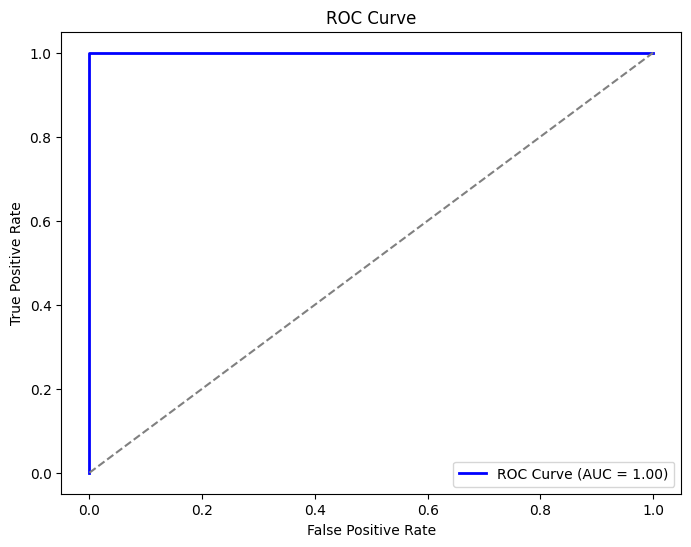

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_nn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()




1.   np.sum(y_train == 0) → Menghitung jumlah pasien dengan label 0 (Tidak Sakit).
2.   np.sum(y_train == 1) → Menghitung jumlah pasien dengan label 1 (Sakit).



In [ ]:
print("Jumlah Pasien Tidak Sakit:", np.sum(y_train == 0))
print("Jumlah Pasien Sakit:", np.sum(y_train == 1))


Jumlah Pasien Tidak Sakit: 341
Jumlah Pasien Sakit: 345


## Menggunakan model yang telah dilatih untuk memprediksi apakah pasien baru memiliki risiko penyakit jantung atau tidak berdasarkan fitur kesehatan mereka.

1. Membuat Data Pasien Baru


*   new_patients = np.array([
    [32, 0, 0, 118, 190, 0, 1, 175, 0, 0.2, 1, 0, 0],
    [65, 1, 3, 160, 250, 1, 2, 130, 1, 2.5, 2, 2, 2],
    [75, 1, 3, 180, 300, 1, 2, 100, 1, 4.0, 2, 3, 2],
    [85, 1, 3, 200, 350, 1, 2, 80, 1, 6.5, 2, 3, 3],
    [25, 0, 1, 110, 180, 0, 0, 190, 0, 0.0, 1, 0, 0]
])

*   7 pasien baru dibuat, dengan kombinasi pasien sehat (Tidak Sakit) dan berisiko tinggi (Sakit).
*   Fitur yang digunakan mencakup usia, tekanan darah, kolesterol, detak jantung, dan lain-lain.

2. Mengubah ke Format DataFrame


*   new_patients_df = pd.DataFrame(new_patients, columns=feature_order)

*   Membuat DataFrame dari array NumPy dengan nama kolom yang sesuai (sesuai urutan dataset utama).

3. Normalisasi Fitur Numerik
* new_patients_df[numerical_features] = scaler.transform(new_patients_df[numerical_features])
* Data pasien baru dinormalisasi menggunakan StandardScaler yang sudah dilatih pada dataset awal.
* Hal ini memastikan bahwa skala fitur tetap sama dengan dataset yang digunakan untuk melatih model.

4. Prediksi dengan Model Neural Network
* new_pred_proba = model_nn.predict(new_patients_df)
new_pred = (new_pred_proba > 0.5).astype("int32")
* Model melakukan prediksi probabilitas apakah pasien memiliki penyakit jantung.

* Jika probabilitas > 0.5, maka pasien dikategorikan memiliki penyakit jantung.

* Jika probabilitas ≤ 0.5, maka pasien dikategorikan tidak memiliki penyakit jantung.

5. Menampilkan Hasil Prediksi
* for i, (prob, pred) in enumerate(zip(new_pred_proba, new_pred)):
    print(f"Pasien {i+1}: Probabilitas = {prob[0]:.4f}, Prediksi = {'Memiliki Penyakit Jantung' if pred[0] == 1 else 'Tidak Memiliki Penyakit Jantung'}")
* Setiap pasien akan ditampilkan probabilitasnya serta hasil prediksi akhir (Sakit/Tidak Sakit).

In [ ]:
new_patients = np.array([
    [32, 0, 0, 118, 190, 0, 1, 175, 0, 0.2, 1, 0, 0],
    [65, 1, 3, 160, 250, 1, 2, 130, 1, 2.5, 2, 2, 2],
    [75, 1, 3, 180, 300, 1, 2, 100, 1, 4.0, 2, 3, 2],
    [85, 1, 3, 200, 350, 1, 2, 80, 1, 6.5, 2, 3, 3],
    [25, 0, 1, 110, 180, 0, 0, 190, 0, 0.0, 1, 0, 0]
])
feature_order = X_train.columns.tolist()
new_patients_df = pd.DataFrame(new_patients, columns=X.columns.tolist())
new_patients_df[numerical_features] = scaler.transform(new_patients_df[numerical_features])
new_pred_proba = model_nn.predict(new_patients_df)
new_pred = (new_pred_proba > 0.5).astype("int32")
for i, (prob, pred) in enumerate(zip(new_pred_proba, new_pred)):
    print(f"Pasien {i+1}: Probabilitas = {prob[0]:.4f}, Prediksi = {'Memiliki Penyakit Jantung' if pred[0] == 1 else 'Tidak Memiliki Penyakit Jantung'}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Pasien 1: Probabilitas = 1.0000, Prediksi = Memiliki Penyakit Jantung
Pasien 2: Probabilitas = 0.0003, Prediksi = Tidak Memiliki Penyakit Jantung
Pasien 3: Probabilitas = 0.0000, Prediksi = Tidak Memiliki Penyakit Jantung
Pasien 4: Probabilitas = 0.0000, Prediksi = Tidak Memiliki Penyakit Jantung
Pasien 5: Probabilitas = 1.0000, Prediksi = Memiliki Penyakit Jantung


## Menggunakan SHAP untuk menganalisis pengaruh fitur terhadap keputusan model Neural Network dalam memprediksi penyakit jantung.
1. Mengimpor SHAP
* SHAP adalah metode explainability yang digunakan untuk memahami bagaimana fitur mempengaruhi prediksi model.

* Menggunakan konsep teori permainan (Shapley values) untuk mengukur kontribusi setiap fitur terhadap hasil prediksi.

2. Membuat Explainer untuk Model
* explainer = shap.Explainer(model_nn, new_patients_df)
* SHAP Explainer dibuat berdasarkan model Neural Network (model_nn).

* Dataset new_patients_df digunakan sebagai referensi untuk menghitung pengaruh setiap fitur dalam model.

3. Menghitung SHAP Values
* shap_values = explainer(new_patients_df)
* SHAP Values dihitung untuk setiap fitur dalam dataset new_patients_df.

* Nilai ini menunjukkan seberapa besar setiap fitur berkontribusi terhadap keputusan model (apakah pasien memiliki penyakit jantung atau tidak).

4. Menampilkan Summary Plot SHAP
* shap.summary_plot(shap_values, new_patients_df)
* Menampilkan pengaruh setiap fitur terhadap prediksi model dalam bentuk Summary Plot.

* Plot ini menunjukkan:

  * Fitur yang paling berpengaruh dalam model.

  * Arah hubungan fitur dengan output (positif/negatif).

  * Distribusi SHAP values di setiap data pasien.

<ipython-input-69-156f0b16011a>:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, new_patients_df)


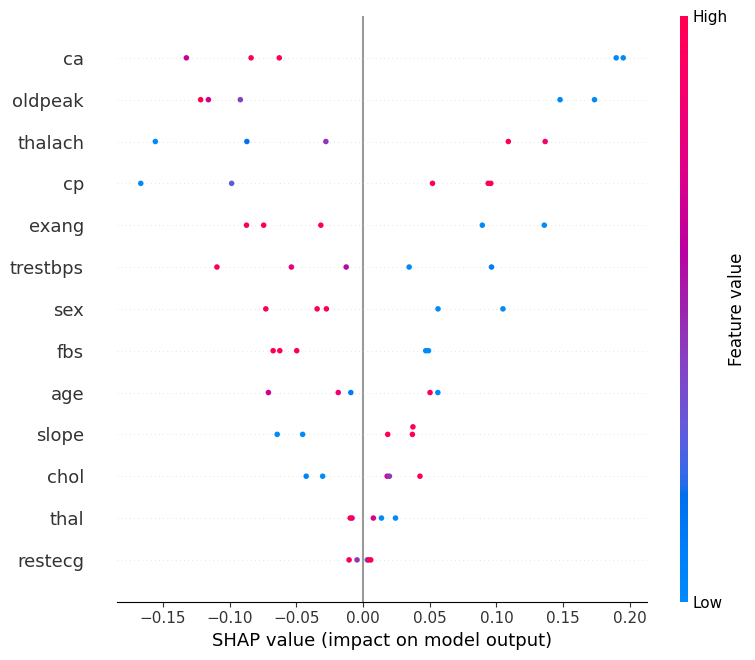

In [ ]:
import shap
explainer = shap.Explainer(model_nn, new_patients_df)
shap_values = explainer(new_patients_df)
shap.summary_plot(shap_values, new_patients_df)


Simpan Hasil model ke dalam model result dengan nama Neural Network untuk nantinya di bandingkan dengan algortima model lain

In [ ]:
model_results["Neural Network"] = {
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn, average='weighted'),
    "Recall": recall_score(y_test, y_pred_nn, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_nn, average='weighted')
}

# Bandingkan Hasil
Algoritma yang dibandingkan:
1. K-Nearest Neighbors (KNN)
2. Support Vector Machine (SVM)
3. Decision Tree
4. Random Forest
5. Artificial Neural Network (ANN)

*  Menyimpan Hasil Evaluasi dalam Dictionary
  * Hasil dari setiap algoritma disimpan dalam dictionary model_results
* Evaluasi Model dan Menyimpan Hasil
  1.) K-Nearest Neighbors (KNN)
    * Model dilatih dengan jumlah tetangga terbaik (best_k = 8).

    * Model diuji dengan X_test, lalu hasil prediksi disimpan.

    * Akurasi, Precision, Recall, dan F1 Score dihitung.

    * Hasilnya dimasukkan ke dalam model_results.

  2.) Support Vector Machine (SVM)
    * Model dilatih menggunakan kernel terbaik (linear).

    * Evaluasi model dilakukan dan hasilnya disimpan.

  3.)Decision Tree
    * Model dilatih dengan max_features = 12.
    * Hasil evaluasi disimpan.

  4.)Random Forest
    * Model dilatih dengan n_estimators = 100.
    * Hasil evaluasi disimpan.

  5.)Neural Network (ANN)
    * Arsitektur model terdiri dari 3 layer:
      * Layer 1: 132 neuron (ReLU)
      * Layer 2: 16 neuron (ReLU)
      * Layer 3: 1 neuron (Sigmoid, untuk klasifikasi biner)
    * Model dilatih selama 50 epochs dengan batch size 16.
    * Setelah training, model diuji dan hasil evaluasi disimpan.

* Menentukan Model Terbaik
  * best_model = df_results["Accuracy"].idxmax() best_score = df_results["Accuracy"].max()
* mencari indeks dengan nilai akurasi tertinggi dan mencetak hasilnya
  * print(f"\n Model terbaik berdasarkan Akurasi: {best_model} dengan skor {best_score:.4f}")




In [ ]:
df_results = pd.DataFrame(model_results).T
print(df_results)
best_model = df_results["Accuracy"].idxmax()
best_score = df_results["Accuracy"].max()
print(f"\nModel terbaik berdasarkan Akurasi: {best_model} dengan skor {best_score:.4f}")

                Accuracy  Precision    Recall  F1 Score
KNN             0.893805   0.896289  0.893805  0.893927
SVM             0.867257   0.870982  0.867257  0.866321
Decision Tree   0.991150   0.991315  0.991150  0.991155
Random Forest   1.000000   1.000000  1.000000  1.000000
Neural Network  1.000000   1.000000  1.000000  1.000000

Model terbaik berdasarkan Akurasi: Random Forest dengan skor 1.0000


### Visualisasi Perbandingan Model Machine Learning

1. plt.figure(figsize=(10, 6))
* Membuat figure utama dengan ukuran 10x6 inch.
2. df_results.plot(kind="bar", figsize=(12, 6), colormap="viridis")	Membuat
* grafik batang dengan skala warna Viridis untuk estetika yang lebih baik.
3. plt.title("Perbandingan Hasil Model Machine Learning")
* Menambahkan judul grafik.
4. plt.xlabel("Model")
* Menambahkan label sumbu X dengan nama "Model".
5. plt.ylabel("Score")
* Menambahkan label sumbu Y dengan nama "Score".
6. plt.ylim(0, 1)
* Mengatur rentang nilai Y antara 0 hingga 1 untuk menjaga konsistensi visual.
7. plt.xticks(rotation=45)
* Memutar label sumbu X sebesar 45 derajat agar lebih mudah dibaca.
8. plt.legend(loc="lower right")
* Menempatkan legenda di kanan bawah grafik.
9. plt.grid(axis="y")
* Menambahkan garis bantu horizontal untuk memudahkan interpretasi nilai.
10. plt.show()
* Menampilkan grafik hasil visualisasi.



<Figure size 1000x600 with 0 Axes>

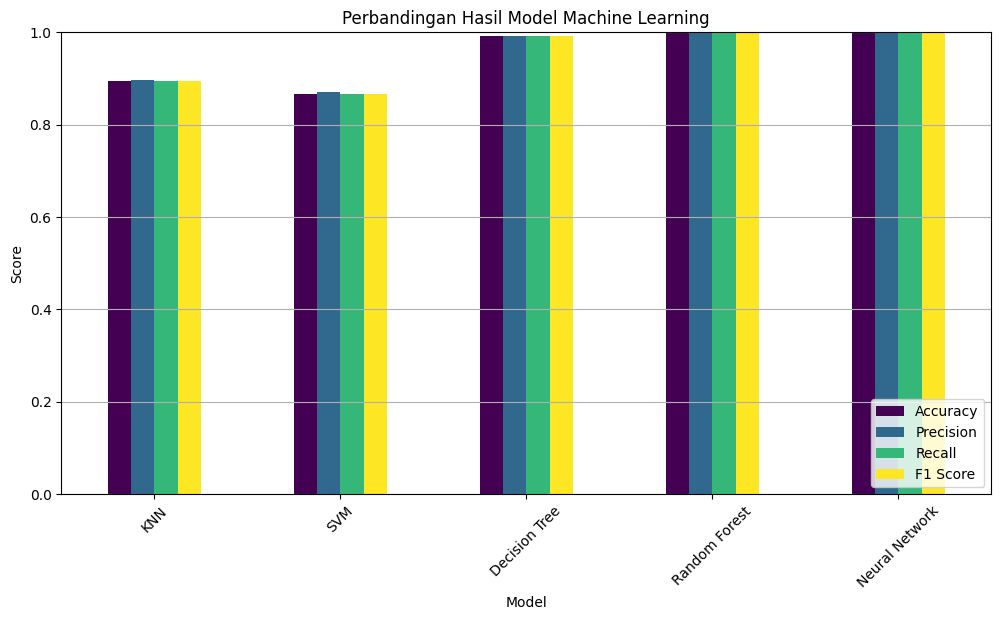

In [ ]:
plt.figure(figsize=(10, 6))
df_results.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Perbandingan Hasil Model Machine Learning")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [ ]:
print("Jumlah sampel dalam dataset:", df.shape[0])

Jumlah sampel dalam dataset: 1025
